In [2]:
import numpy as np

import matplotlib.pyplot as plt
import scipy
import pandas as pd



colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

### Discrete Levels

In [4]:
# the discrete levels 

# Match the ROOT macro
a0 = -0.7590
a1 = 0.3000

# --- Load rholev.cnt (one value per line or whitespace-separated) ---
levels = np.loadtxt("input_data/rholev.txt", dtype=float).ravel()

# Use the first 30 entries, just like TGraph(30, energy, levels)
n = min(30, levels.size)
levels = levels[:n]

# X-values used for the "level" graph in the macro
energy_levels = a0 + a1 * np.arange(n)



### Oslo data

In [5]:
# reading the oslo data for 300 bin (6,9)

df=pd.read_csv("input_data/100Z_ld.csv")



df_new = df.copy()

# convert to python arrays
energy=df_new["energy"].values # as numpy array
ld=df_new["ld"].values 
error=df_new["errors"].values




### Median of all slopes

In [17]:
alphas= np.loadtxt("output_data/gsf_post.txt")
alphas_new= alphas[:,4]


median = np.median(alphas_new)
print("median:",median)

ld_c = ld * np.exp(-median* energy)
error_c = error*  np.exp(-median* energy)


median: -0.1298335


### pulling master base data of NLD for interpolation and storing values

In [18]:
# interpolation
df_p =pd.read_pickle("interp_data/master_base_ld_p.pkl")
df_n = pd.read_pickle("interp_data/master_base_ld_n.pkl")

# for storing new values
df_base_p =pd.read_pickle("interp_data/base_ld_p.pkl")
df_base_n = pd.read_pickle("interp_data/base_ld_n.pkl")



### NLD parameters 

In [13]:
alpha_rand= np.load("output_data/nld_post.npy")

print(alpha_rand.shape)

(30000, 2)


### Constructructing TALYS2.0 models to draw the resultant band produced by parameter sampling

In [14]:
df_param_p = df_base_p.copy()
df_param_n = df_base_n.copy()    


def model_ld(params):
    df1 = df_param_p.copy()
    df2 = df_param_n.copy()

    ctable_vis= 0.0
    ptable_vis= 0.0
    
    ctable = params[0]+ctable_vis
    ptable = params[1]+ptable_vis
    

    new_energy = df1['Ex'].values - ptable

    # for postive_ld
    for col in df1.columns[1:]:
        shifted_values = np.interp(new_energy, df_p['Ex'].values, df_p[col].values)
        new_values = np.exp(ctable* np.sqrt(np.abs(new_energy)))* shifted_values
        df1[col] = new_values
    
    new_energy = df2['Ex'].values - ptable
    
    # for negative_ld
    for col in df2.columns[1:]:
        shifted_values = np.interp(new_energy, df_n['Ex'].values, df_n[col].values)
        new_values = np.exp(ctable* np.sqrt(np.abs(new_energy)))* shifted_values
        df2[col] = new_values
    
    
    df_end= df1.set_index('Ex').add(df2.set_index('Ex'), fill_value=0).reset_index()
    
    df_end['ld_eff']=df_end['JP=0.0']+df_end['JP=1.0']+df_end['JP=2.0']+ +df_end['JP=3.0']
    
    #df_final=df_final[df_final['Ex

    ld_eff_np=  df_end['ld_eff'].values

    return ld_eff_np

In [15]:
np.random.seed(142857)
func_rand=[model_ld(alpha) for alpha in alpha_rand]

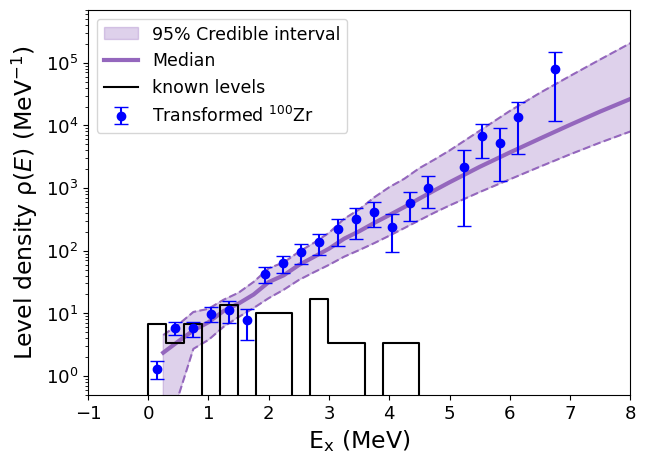

In [21]:

plt.rcParams['figure.figsize']=(10.4,5.4)

fig, ax = plt.subplots(figsize=(7,5),dpi=100)
median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))
lower = (np.percentile(func_rand, 2.5, axis = 0))


prediction_color_number=4

energy_t =df_param_p['Ex'].values
ax.fill_between(energy_t, lower, upper, color=colors[prediction_color_number], alpha=0.3,label='95% Credible interval')


ax.plot(energy_t, median, color=colors[prediction_color_number],linewidth=3,label='Median')
ax.plot(energy_t, lower, color=colors[prediction_color_number],linestyle='dashed')
ax.plot(energy_t, upper, color=colors[prediction_color_number],linestyle='dashed')


ax.errorbar(energy, ld_c, yerr=error_c, color ='blue', ecolor='blue',fmt='o', capsize=5,label='Transformed $^{100}$Zr')


plt.step(energy_levels, levels, '-',color='black', where='mid',label ='known levels')




plt.yscale("log")


plt.xlim(-1,8)
plt.ylim(0.5,700000)






ax.set_xlabel(r'$\mathrm{E_{x}}$ (MeV)',fontsize=17)
ax.set_ylabel(r"Level density $\mathrm{\rho}(E)$ (MeV$^{-1}$)",fontsize=17)


plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)


plt.legend(loc ='upper left', fontsize=12.5)



plt.show()